<img src="https://cmse.msu.edu/_assets/images/about/image001.png"
     alt="CMSE Logo"
     align="right" 
     height="400" 
     width="400" />
# CMSE 801 - Day 25
## Finding model parameters using Markov Chain Monte Carlo (MCMC)
### Algorithm: [Metropolis-Hastings](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm)
#### April 16, 2026

## General Course Announcements

* Final version of your project notebook is due **April 20 by 11:59pm**.
    * We randomly assigned presentation days on Tuesday.
    * Your presentation will be **strictly limited to 4 minutes**.
    * You will be getting project credit for observing and rating your peers, so you are expected to attend both presentation days.
* You can continue to work on your slides after that deadline and up until you present.
* Homework 5 is due **Saturday, April 18, by 11:59pm**.

## Questions/comments from Day 25 PCA

* Biggest challenge was just putting all of the pieces together in order to calculate $\chi^2$ for all combinations of A and B.
* Some questions about interpreting the result.


## How do when know when we've found the "best fit" for our data?

* Once we have a model that we think is a good choice for our data, there are a variety of ways that we can try to find the best fit.
* A "brute force" approach is to simply explore as much of parameter space as possible and test all the possible combinations of model parameters that we think are reasonable. This can be effective, but *time consuming*, especially for models with a lot of parameters!
    * We'll review this "grid search" approach from the PCA.
* There are more sophisticated ways of doing this, including a class of algorithms referred to as Markov Chain Monte Carlo methods.
    * We'll explore the Metropolis-Hastings algorithm in today's session.

## Functions for setting up some data and calculating model values

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns; sns.set_style("ticks"); sns.set_context("talk")

def generate_model_and_data(A,B,sigma=0.5,data_points=10):
    '''
    Creates a simple set of data points in a parabola that has 
    noise added in the y-direction.  The user can control the parabola
    properties (A and B) as well as the noise level and number of data
    points.  Returns x and (noisy) y values.
    '''
    x = np.linspace(-5,5,data_points)
    y = A*x**2 + B 
    y_noisy = y + np.random.normal(0.0,sigma,data_points)

    return x, y, y_noisy

def estimate_model_vals(A,B,x):
    '''
    Given x-values and our MCMC code's estimates for A and B, this returns 
    estimated y values that we can compare to the actual data .
    '''
    return A*x**2 + B   

## Let's set up our initial data and visualize it based on the input parameters

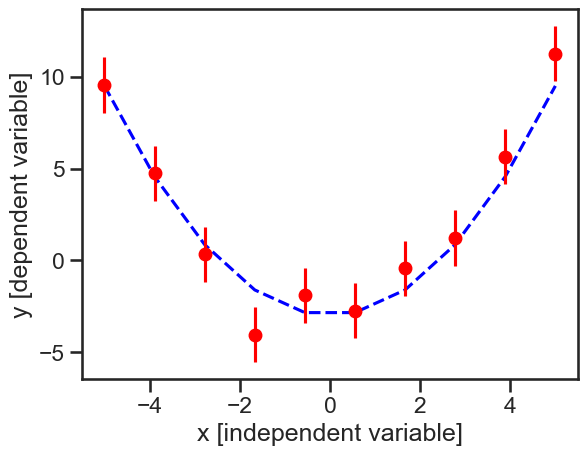

In [2]:
'''
---------------- USER SETS THESE! ----------------
 A_user = parabola width
 B_user = y-axis intercept
 sigma = error added to the y-values (the noise)
 data_points = number of data points we want to use
'''

A_user = 0.5
B_user = -3
sigma = 1.5
data_points=10

# now we're going to generate a model and create artificial "data" with some error in it.
x_data, y_model, y_data = generate_model_and_data(A_user,B_user,sigma,data_points)

# plot the "data" so we can see what's going on!
# Note: if you make A too big, it may be hard to see the errors.
plt.plot(x_data,y_model,'b--')
plt.ylabel("y [dependent variable]")
plt.xlabel("x [independent variable]")
plt.errorbar(x_data, y_data, yerr=sigma, fmt='ro');

## Create a function for calculating our reduce chi-squared value
#### This is our "goodness of fit" metric
$$ \chi_R^2 = \frac{1}{N_{pts}}\sum_i \frac{(y_{data,i} - y_{model,i})^2}{2 \sigma_i^2} $$

In [3]:
def chi_squared_error(ydata,ymodel,error):
    '''
    Takes in the observed data, our model's estimated y-values 
    for the model, and our estimate for the errors in the data.
    
    Returns sum-of-squares error (chi-squared error) 
    '''
    
    return ((ydata-ymodel)**2/(2*error**2)).sum()/(ydata.size)

## Now we set up a "grid" of parameter values and explore parameter space to find the "best fit"

In [4]:
Astart = -4
Aend = 4
deltaA = 0.1

Bstart = -10
Bend = 8
deltaB = 0.2

Avalues, Bvalues = np.mgrid[Astart:Aend:deltaA, Bstart:Bend:deltaB]

chisquared_grid = np.zeros_like(Avalues)

# Loop over my grid
for i in range(chisquared_grid.shape[0]):
    for j in range(chisquared_grid.shape[1]):
        # Calculate estimated model values based on the parameters at each location in the grid
        this_model = estimate_model_vals(Avalues[i,j],Bvalues[i,j],x_data)
        # Calculate and store the chi-squared value at each location
        chisquared_grid[i,j] = chi_squared_error(this_model, y_data, sigma)

print("min, max error values are:", chisquared_grid.min(),chisquared_grid.max())

min, max error values are: 0.2716302849148278 995.4895221910037


## And then we can visualize it

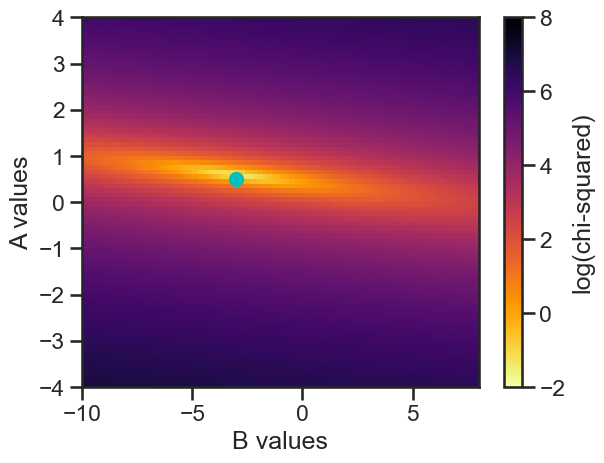

In [5]:
# take the log of chi-squared
log_chisquared_grid = np.log(chisquared_grid)

# make the log of chi-squared, with a lot of optional arguments to make
# everything look nice and show the correct values. Look at the documentation
# for plt.imshow() to see what all of these mean!
plt.imshow(log_chisquared_grid,interpolation='none',
                    extent=(Bstart,Bend,Astart,Aend),aspect='auto',
                    origin='lower',cmap='inferno_r')
plt.ylabel("A values")
plt.xlabel("B values")
cb = plt.colorbar()
cb.set_label("log(chi-squared)")
plt.clim(-2,8)

# plot a cyan dot in the user-defined values.
plt.plot(B_user,A_user,'co',markersize=10);

<img src="http://wiki.ubc.ca/images/thumb/f/f3/MCMCTraversal.png/500px-MCMCTraversal.png" width=300px align="right">

## Overview of the Metropolis-Hastings "Random Walk" MCMC algorithm

Basic summary of the process:
* **Step 1**: Take an initial guess for your possible best fit parameters.
* **Step 2**: Calculated the reduced chi-squared value for that guess.
* **Step 3**: Randomly shift your model parameters (independently) based on a "step size" parameter, which you can vary. Use this as your new guess.
* **Step 4**: Calculated the reduced chi-squared for this guess.
* **Step 5**: Use the "old" chi-squared value and the "new" chi-squared value to calculate a probability for determining if we move to the new guess's location.
* **Step 6**: "Roll the dice" to decide if we move to the new location. If yes, move. If not, choose a new random step and try again.
* **Step 7**: Repeat this process for a predetermined number of steps.




## Goals for today
* Practice implementing the Metropolis-Hastings algorithm for simulated test data.
* Visualize your visualize the resulting sampling of parameter space.